# BLOSUM62 Amino Acid Substitution Heatmap

Pull the BLOSUM62 matrix from Biopython and visualize it as a heatmap showing substitution scores between all 20 standard amino acids.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio.Align import substitution_matrices
from rdkit import Chem

# Load BLOSUM62
blosum62 = substitution_matrices.load("BLOSUM62")

# Compute side chain atom counts
aa_smiles = {
    "A": "NC(C)C(=O)O", "R": "NC(CCCNC(=N)N)C(=O)O",
    "N": "NC(CC(=O)N)C(=O)O", "D": "NC(CC(=O)O)C(=O)O",
    "C": "NC(CS)C(=O)O", "E": "NC(CCC(=O)O)C(=O)O",
    "Q": "NC(CCC(=O)N)C(=O)O", "G": "NCC(=O)O",
    "H": "NC(Cc1c[nH]cn1)C(=O)O", "I": "NC(C(CC)C)C(=O)O",
    "L": "NC(CC(C)C)C(=O)O", "K": "NC(CCCCN)C(=O)O",
    "M": "NC(CCSC)C(=O)O", "F": "NC(Cc1ccccc1)C(=O)O",
    "P": "OC(=O)C1CCCN1", "S": "NC(CO)C(=O)O",
    "T": "NC(C(O)C)C(=O)O", "V": "NC(C(C)C)C(=O)O",
    "W": "NC(Cc1c[nH]c2ccccc12)C(=O)O", "Y": "NC(Cc1ccc(O)cc1)C(=O)O",
}
sidechain_counts = {}
for aa, smi in aa_smiles.items():
    mol = Chem.AddHs(Chem.MolFromSmiles(smi))
    sidechain_counts[aa] = mol.GetNumAtoms() - 9

# Amino acids grouped by biochemical property, sorted within each group by side chain size
groups = [
    sorted("AVILMFYW", key=lambda aa: sidechain_counts[aa]),  # Hydrophobic
    sorted("STNQ",     key=lambda aa: sidechain_counts[aa]),   # Polar uncharged
    sorted("CGP",      key=lambda aa: sidechain_counts[aa]),   # Special
    sorted("RHK",      key=lambda aa: sidechain_counts[aa]),   # Positively charged
    sorted("DE",       key=lambda aa: sidechain_counts[aa]),   # Negatively charged
]
amino_acids = [aa for group in groups for aa in group]

# Build DataFrame in grouped order
data = np.zeros((20, 20))
for i, aa1 in enumerate(amino_acids):
    for j, aa2 in enumerate(amino_acids):
        data[i, j] = blosum62[aa1, aa2]

df = pd.DataFrame(data, index=amino_acids, columns=amino_acids)

# Group boundary positions
group_boundaries = np.cumsum([len(g) for g in groups])[:-1]

# Print ordering
for g, name in zip(groups, ["Hydrophobic", "Polar uncharged", "Special", "Positive", "Negative"]):
    print(f"{name}: {', '.join(f'{aa}({sidechain_counts[aa]})' for aa in g)}")

Hydrophobic: A(4), V(10), M(11), I(13), L(13), F(14), Y(15), W(18)
Polar uncharged: S(5), T(8), N(8), Q(11)
Special: G(1), C(5), P(8)
Positive: H(11), K(15), R(17)
Negative: D(7), E(10)


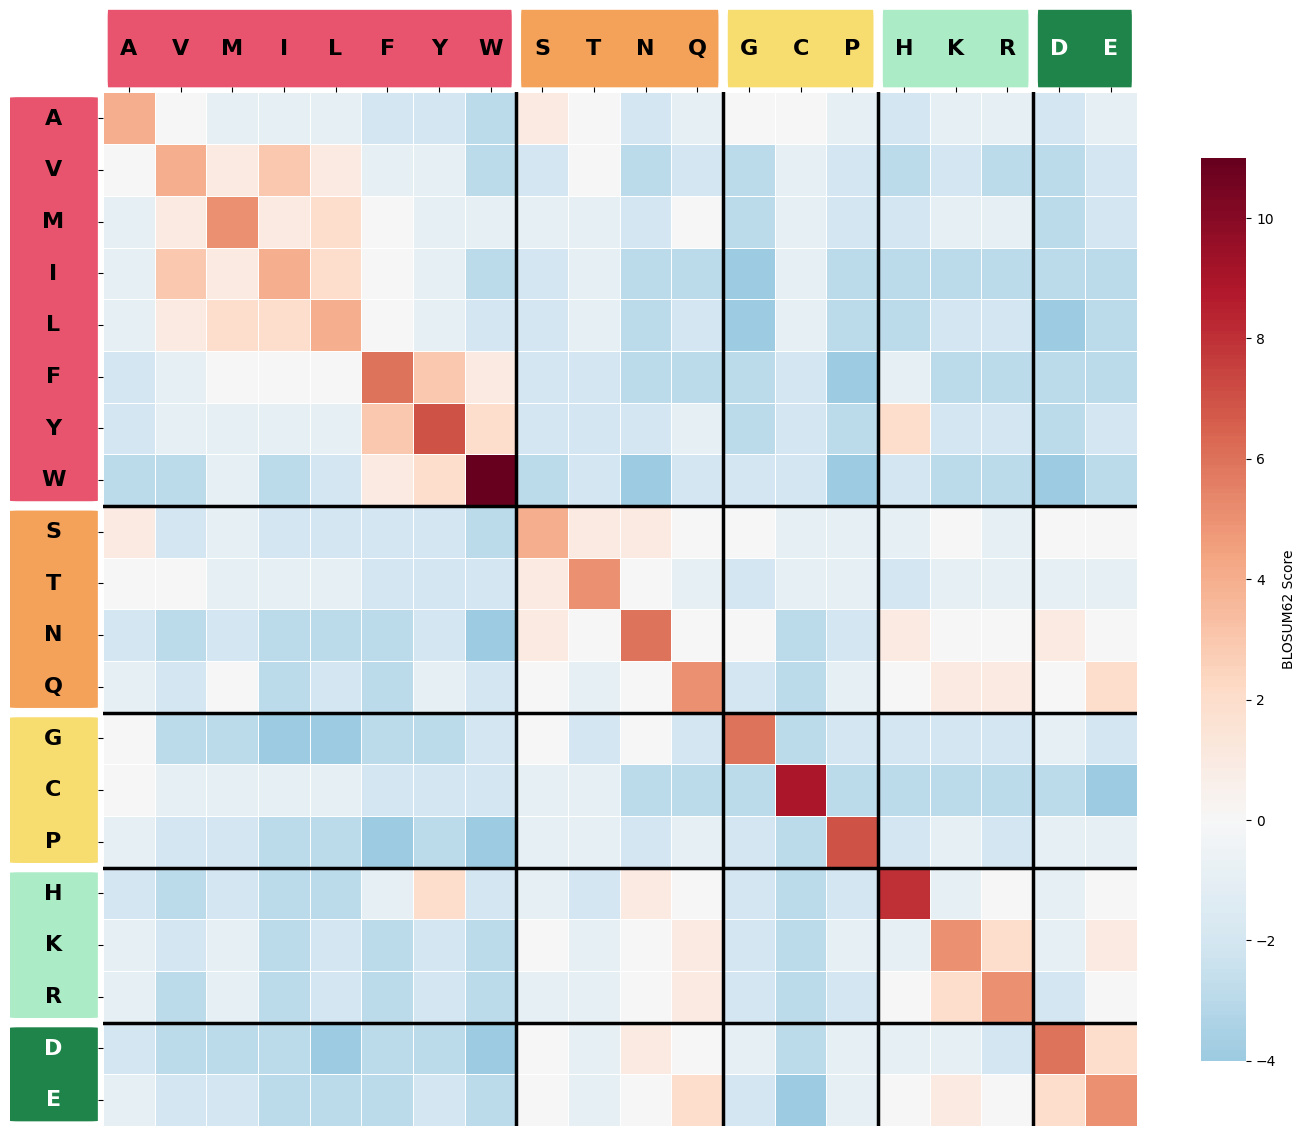

In [32]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import blended_transform_factory

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    df,
    annot=False,
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "BLOSUM62 Score", "shrink": 0.8},
    ax=ax,
)

# Draw thick lines at group boundaries
for b in group_boundaries:
    ax.axhline(y=b, color="black", linewidth=2.5)
    ax.axvline(x=b, color="black", linewidth=2.5)

# Move x-axis to top, then hide default tick labels
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])
# Group colors
group_colors = [
    "#E8546D",  # Pinkish red - Hydrophobic
    "#F4A259",  # Orangish - Polar uncharged
    "#F7DC6F",  # Yellow - Special
    "#ABEBC6",  # Light green - Positive
    "#1E8449",  # Dark green - Negative
]

starts = [0] + list(group_boundaries)
sizes = [len(g) for g in groups]

# Y-axis (left) highlight bands
trans_y = blended_transform_factory(ax.transAxes, ax.transData)
for start, size, color in zip(starts, sizes, group_colors):
    rect = FancyBboxPatch(
        (-0.08, start + 0.1), 0.065, size - 0.2,
        transform=trans_y, clip_on=False,
        facecolor=color, edgecolor="none",
        boxstyle="round,pad=0.01",
    )
    ax.add_patch(rect)

# X-axis (top) highlight bands
trans_x = blended_transform_factory(ax.transData, ax.transAxes)
for start, size, color in zip(starts, sizes, group_colors):
    rect = FancyBboxPatch(
        (start + 0.1, 1.015), size - 0.2, 0.055,
        transform=trans_x, clip_on=False,
        facecolor=color, edgecolor="none",
        boxstyle="round,pad=0.01",
    )
    ax.add_patch(rect)

# Draw custom tick labels on top of the bands
for i, aa in enumerate(amino_acids):
    color = "white" if i >= starts[-1] else "black"
    # Y-axis labels (left)
    ax.text(
        -0.048, i + 0.5, aa,
        transform=trans_y, ha="center", va="center",
        fontsize=16, fontweight="bold", color=color, clip_on=False,
    )
    # X-axis labels (top)
    ax.text(
        i + 0.5, 1.042, aa,
        transform=trans_x, ha="center", va="center",
        fontsize=16, fontweight="bold", color=color, clip_on=False,
    )

plt.tight_layout()
plt.show()

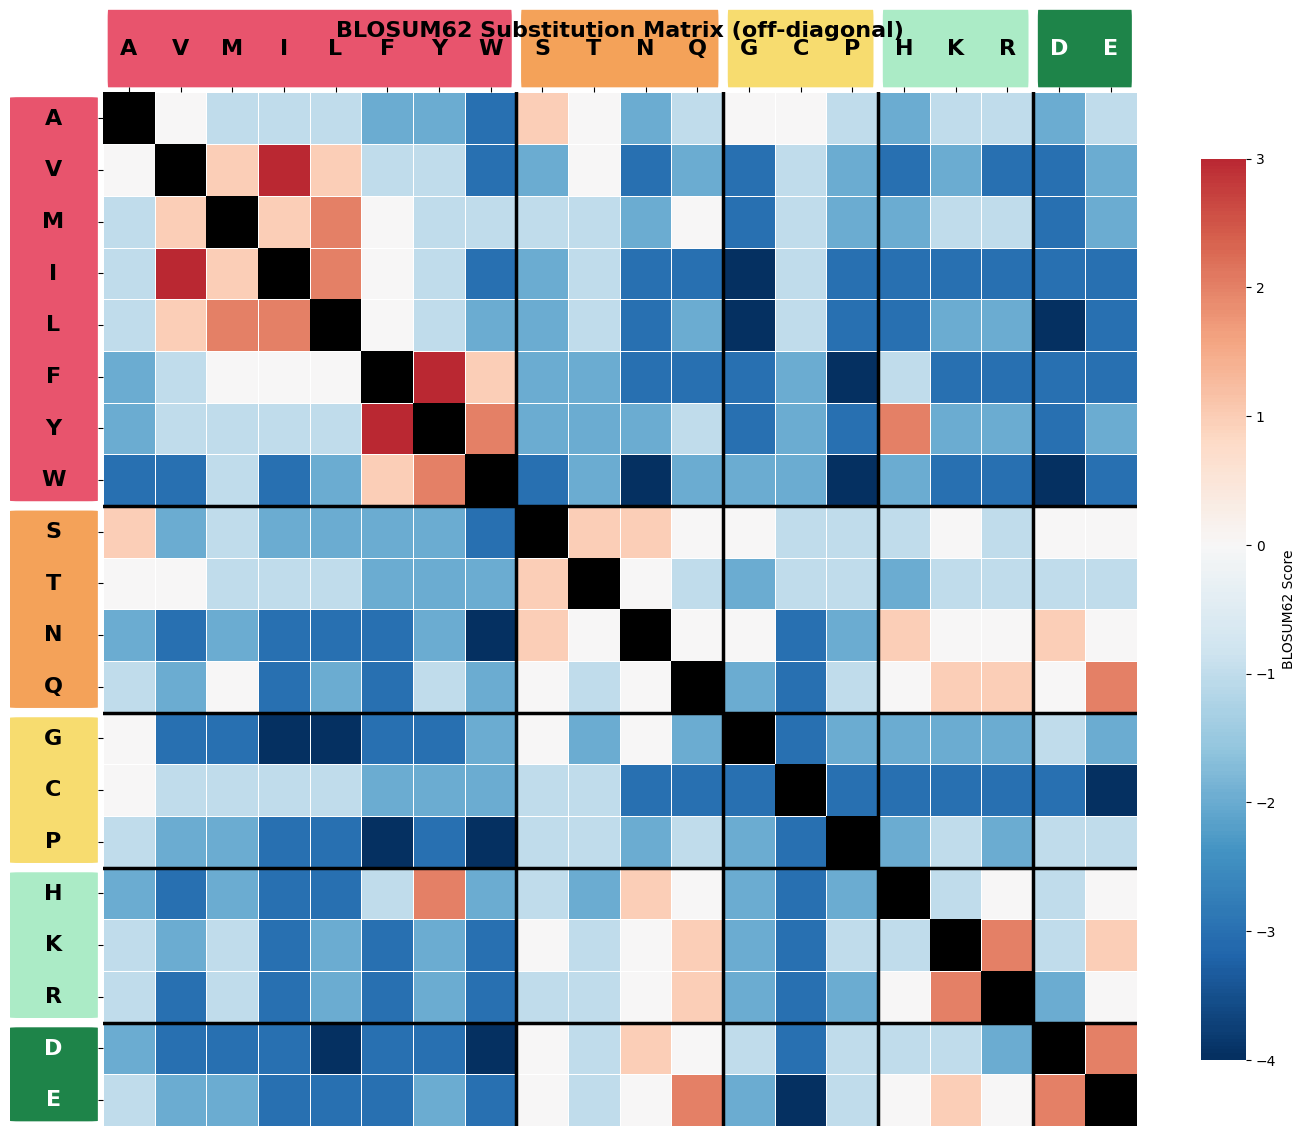

In [33]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import blended_transform_factory

# Mask the diagonal
mask = np.eye(20, dtype=bool)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    df,
    annot=False,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "BLOSUM62 Score", "shrink": 0.8},
    ax=ax,
)

# Fill masked diagonal cells with black
for i in range(20):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, facecolor="black", edgecolor="none"))

# Draw thick lines at group boundaries
for b in group_boundaries:
    ax.axhline(y=b, color="black", linewidth=2.5)
    ax.axvline(x=b, color="black", linewidth=2.5)

# Move x-axis to top, then hide default tick labels
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])

ax.set_title("BLOSUM62 Substitution Matrix (off-diagonal)", fontsize=16, fontweight="bold", pad=40)

starts = [0] + list(group_boundaries)
sizes = [len(g) for g in groups]

# Y-axis (left) highlight bands
trans_y = blended_transform_factory(ax.transAxes, ax.transData)
for start, size, color in zip(starts, sizes, group_colors):
    rect = FancyBboxPatch(
        (-0.08, start + 0.1), 0.065, size - 0.2,
        transform=trans_y, clip_on=False,
        facecolor=color, edgecolor="none",
        boxstyle="round,pad=0.01",
    )
    ax.add_patch(rect)

# X-axis (top) highlight bands
trans_x = blended_transform_factory(ax.transData, ax.transAxes)
for start, size, color in zip(starts, sizes, group_colors):
    rect = FancyBboxPatch(
        (start + 0.1, 1.015), size - 0.2, 0.055,
        transform=trans_x, clip_on=False,
        facecolor=color, edgecolor="none",
        boxstyle="round,pad=0.01",
    )
    ax.add_patch(rect)

# Draw custom tick labels on top of the bands
for i, aa in enumerate(amino_acids):
    color = "white" if i >= starts[-1] else "black"
    ax.text(
        -0.048, i + 0.5, aa,
        transform=trans_y, ha="center", va="center",
        fontsize=16, fontweight="bold", color=color, clip_on=False,
    )
    ax.text(
        i + 0.5, 1.042, aa,
        transform=trans_x, ha="center", va="center",
        fontsize=16, fontweight="bold", color=color, clip_on=False,
    )

plt.tight_layout()
plt.show()

In [34]:
from rdkit import Chem

# SMILES for all 20 standard amino acids (neutral free form)
aa_smiles = {
    "A": "NC(C)C(=O)O",
    "R": "NC(CCCNC(=N)N)C(=O)O",
    "N": "NC(CC(=O)N)C(=O)O",
    "D": "NC(CC(=O)O)C(=O)O",
    "C": "NC(CS)C(=O)O",
    "E": "NC(CCC(=O)O)C(=O)O",
    "Q": "NC(CCC(=O)N)C(=O)O",
    "G": "NCC(=O)O",
    "H": "NC(Cc1c[nH]cn1)C(=O)O",
    "I": "NC(C(CC)C)C(=O)O",
    "L": "NC(CC(C)C)C(=O)O",
    "K": "NC(CCCCN)C(=O)O",
    "M": "NC(CCSC)C(=O)O",
    "F": "NC(Cc1ccccc1)C(=O)O",
    "P": "OC(=O)C1CCCN1",
    "S": "NC(CO)C(=O)O",
    "T": "NC(C(O)C)C(=O)O",
    "V": "NC(C(C)C)C(=O)O",
    "W": "NC(Cc1c[nH]c2ccccc12)C(=O)O",
    "Y": "NC(Cc1ccc(O)cc1)C(=O)O",
}

# Count total atoms (including implicit hydrogens)
atom_counts = {}
for aa, smi in aa_smiles.items():
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    atom_counts[aa] = mol.GetNumAtoms()

# Side chain atoms = total - 9 (backbone: N, Cα, C', 2O, 2H_N, H_Cα, H_OH)
sidechain_counts = {aa: total - 9 for aa, total in atom_counts.items()}

# Sort by side chain atom count, then alphabetically for ties
aa_by_sidechain = sorted(sidechain_counts.keys(), key=lambda aa: (sidechain_counts[aa], aa))

for aa in aa_by_sidechain:
    print(f"{aa}: {sidechain_counts[aa]} side chain atoms ({atom_counts[aa]} total)")

G: 1 side chain atoms (10 total)
A: 4 side chain atoms (13 total)
C: 5 side chain atoms (14 total)
S: 5 side chain atoms (14 total)
D: 7 side chain atoms (16 total)
N: 8 side chain atoms (17 total)
P: 8 side chain atoms (17 total)
T: 8 side chain atoms (17 total)
E: 10 side chain atoms (19 total)
V: 10 side chain atoms (19 total)
H: 11 side chain atoms (20 total)
M: 11 side chain atoms (20 total)
Q: 11 side chain atoms (20 total)
I: 13 side chain atoms (22 total)
L: 13 side chain atoms (22 total)
F: 14 side chain atoms (23 total)
K: 15 side chain atoms (24 total)
Y: 15 side chain atoms (24 total)
R: 17 side chain atoms (26 total)
W: 18 side chain atoms (27 total)


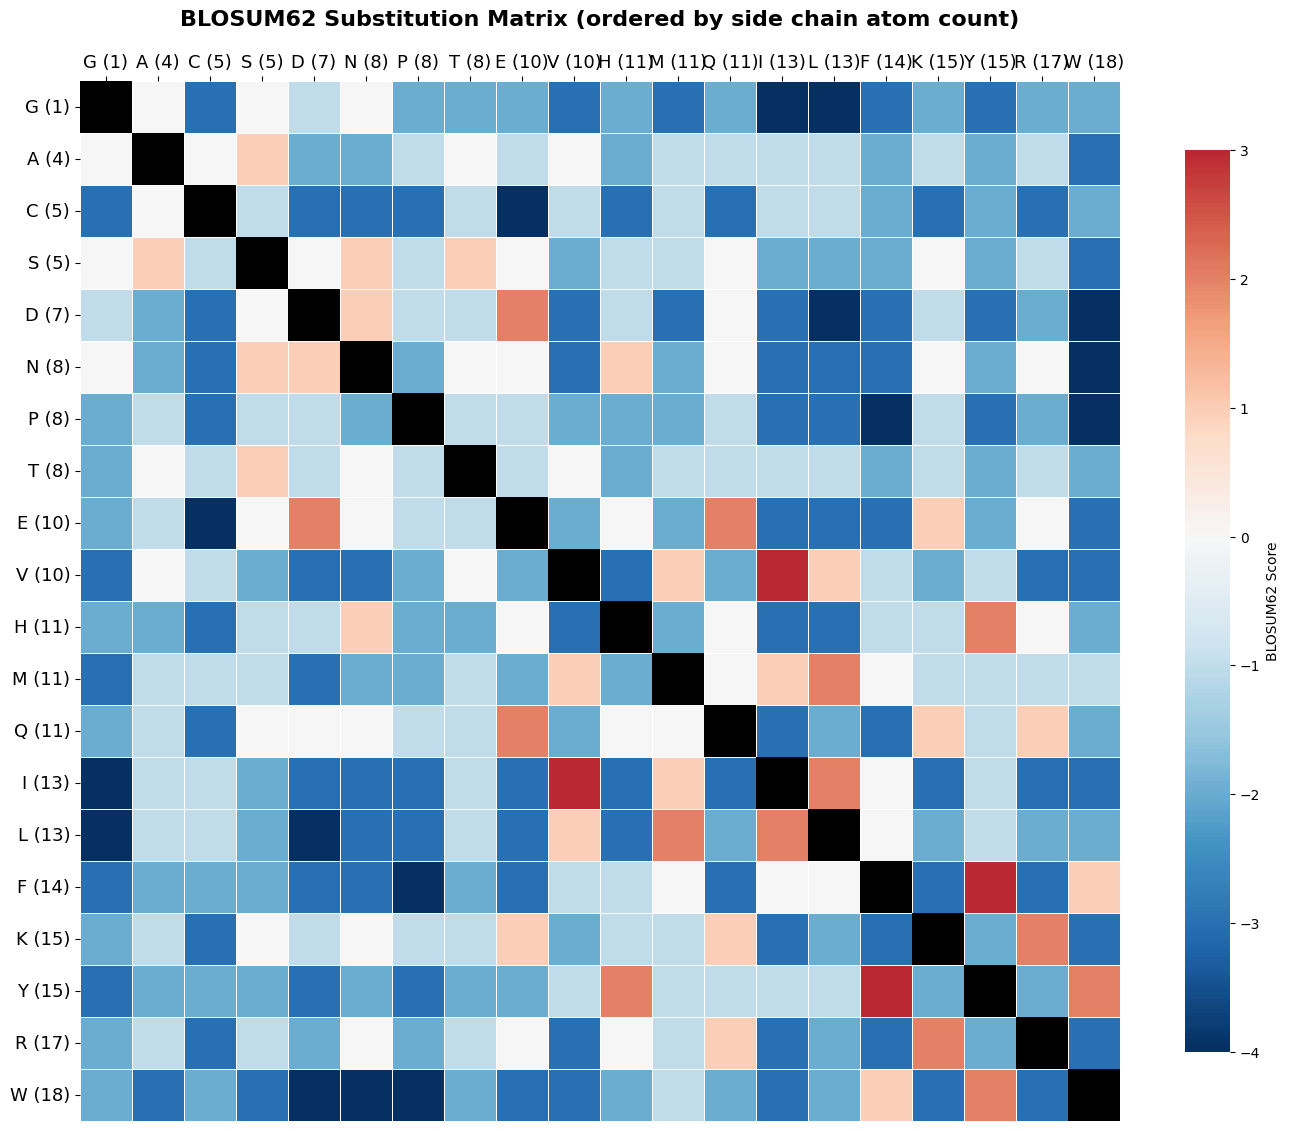

In [35]:
# Build DataFrame ordered by side chain atom count
data_sc = np.zeros((20, 20))
for i, aa1 in enumerate(aa_by_sidechain):
    for j, aa2 in enumerate(aa_by_sidechain):
        data_sc[i, j] = blosum62[aa1, aa2]

labels_sc = [f"{aa} ({sidechain_counts[aa]})" for aa in aa_by_sidechain]
df_sc = pd.DataFrame(data_sc, index=labels_sc, columns=labels_sc)

# Mask diagonal
mask = np.eye(20, dtype=bool)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    df_sc,
    annot=False,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "BLOSUM62 Score", "shrink": 0.8},
    ax=ax,
)

# Fill masked diagonal cells with black
for i in range(20):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, facecolor="black", edgecolor="none"))

# Move x-axis to top
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=13)

ax.set_title("BLOSUM62 Substitution Matrix (ordered by side chain atom count)", fontsize=16, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

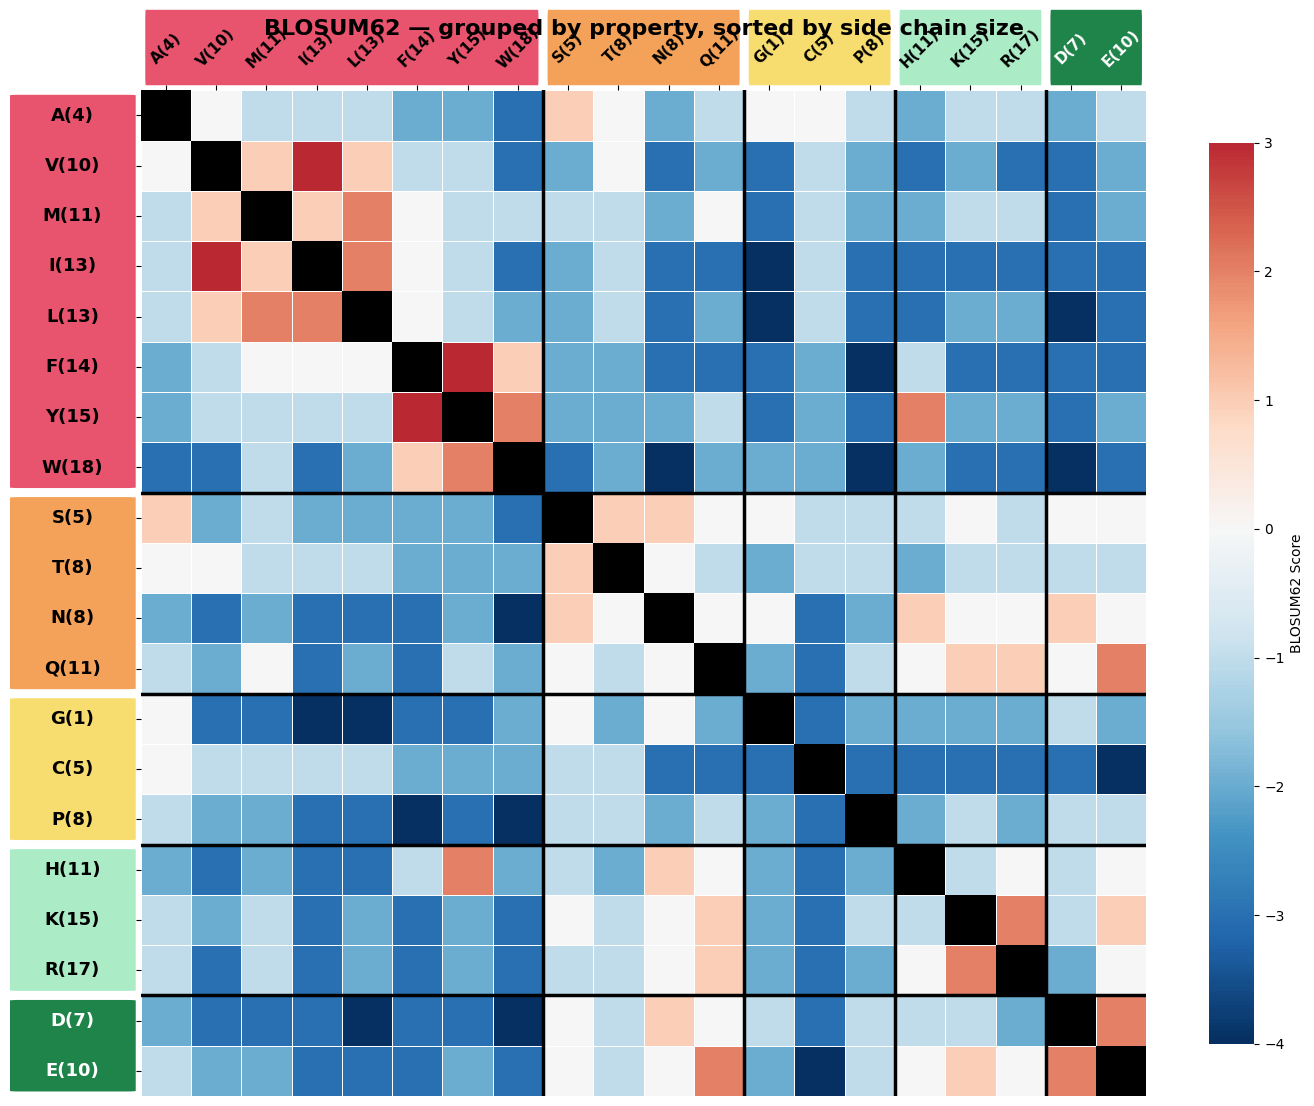

In [36]:
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import blended_transform_factory

# Mask the diagonal
mask = np.eye(20, dtype=bool)

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    df,
    annot=False,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "BLOSUM62 Score", "shrink": 0.8},
    ax=ax,
)

# Fill masked diagonal cells with black
for i in range(20):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, facecolor="black", edgecolor="none"))

# Draw thick lines at group boundaries
for b in group_boundaries:
    ax.axhline(y=b, color="black", linewidth=2.5)
    ax.axvline(x=b, color="black", linewidth=2.5)

# Move x-axis to top, then hide default tick labels
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_yticklabels([])

ax.set_title("BLOSUM62 — grouped by property, sorted by side chain size", fontsize=16, fontweight="bold", pad=40)

# Group colors
group_colors = [
    "#E8546D",  # Pinkish red - Hydrophobic
    "#F4A259",  # Orangish - Polar uncharged
    "#F7DC6F",  # Yellow - Special
    "#ABEBC6",  # Light green - Positive
    "#1E8449",  # Dark green - Negative
]

starts = [0] + list(group_boundaries)
sizes = [len(g) for g in groups]

# Y-axis (left) highlight bands
trans_y = blended_transform_factory(ax.transAxes, ax.transData)
for start, size, color in zip(starts, sizes, group_colors):
    rect = FancyBboxPatch(
        (-0.12, start + 0.1), 0.105, size - 0.2,
        transform=trans_y, clip_on=False,
        facecolor=color, edgecolor="none",
        boxstyle="round,pad=0.01",
    )
    ax.add_patch(rect)

# X-axis (top) highlight bands
trans_x = blended_transform_factory(ax.transData, ax.transAxes)
for start, size, color in zip(starts, sizes, group_colors):
    rect = FancyBboxPatch(
        (start + 0.1, 1.015), size - 0.2, 0.055,
        transform=trans_x, clip_on=False,
        facecolor=color, edgecolor="none",
        boxstyle="round,pad=0.01",
    )
    ax.add_patch(rect)

# Draw custom tick labels with side chain atom counts
for i, aa in enumerate(amino_acids):
    color = "white" if i >= starts[-1] else "black"
    label = f"{aa}({sidechain_counts[aa]})"
    # Y-axis labels (left)
    ax.text(
        -0.068, i + 0.5, label,
        transform=trans_y, ha="center", va="center",
        fontsize=13, fontweight="bold", color=color, clip_on=False,
    )
    # X-axis labels (top)
    ax.text(
        i + 0.5, 1.042, label,
        transform=trans_x, ha="center", va="center",
        fontsize=11, fontweight="bold", color=color, clip_on=False,
        rotation=45,
    )

plt.tight_layout()
plt.show()